In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/raw/superstore.csv', encoding ='latin1')

In [3]:
df.head()  #displays top 5 rows

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.tail() #displays bottom 5 rows

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [5]:
df.shape #displays the number of rows and columns

(9994, 21)

In [6]:
df.columns.tolist() #list of column names

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [7]:
df.dtypes #displays the data types of each columns

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [8]:
df.isnull().sum() #checks for null values in each column

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
# fix the date columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df.dtypes[['Order Date', 'Ship Date']]

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
# feature engineering (creating useful columns for analysis)
df["Order Month"] = df['Order Date'].dt.to_period('M')  # displays year and month
df["Order Year"] = df['Order Date'].dt.year 
df["Order Quarter"] = df['Order Date'].dt.quarter
df["Profit Margin"] = df['Profit']/df['Sales'] 
df["Shipping Days"] = (df['Ship Date'] - df['Order Date']).dt.days

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Quarter,Profit Margin,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11,2016,4,0.1600,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11,2016,4,0.3000,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06,2016,2,0.4700,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10,2015,4,-0.4000,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10,2015,4,0.1125,7


In [15]:
# Overall KPIs
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = total_sales / total_orders

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profits: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Avg Order Value: ${avg_order_value:,.2f}")

Total Sales: $2,297,200.86
Total Profits: $286,397.02
Total Orders: 5009
Avg Order Value: $458.61


In [16]:
import matplotlib.pyplot as plt

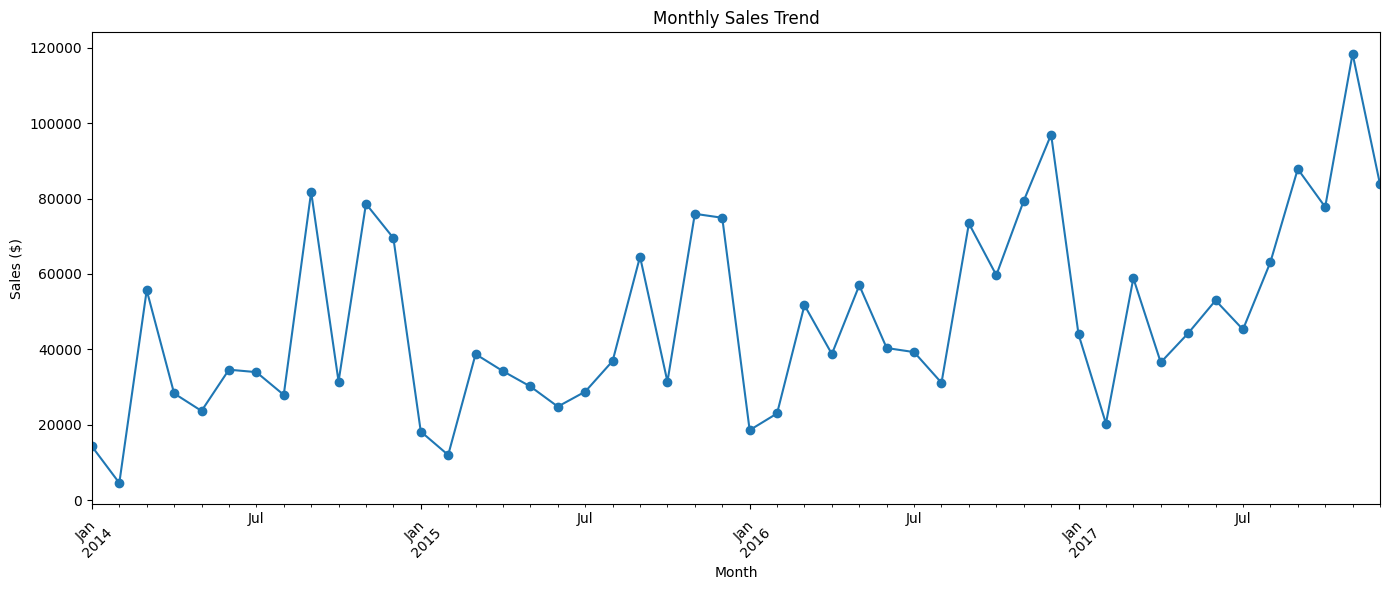

In [17]:
monthly_sales = df.groupby("Order Month")["Sales"].sum()

plt.figure(figsize = (14, 6))
monthly_sales.plot(kind = 'line', marker = 'o')
plt.title('Monthly Sales Trend')
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [19]:
category_perf = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending = False)
subcat_perf = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values('Profit')

print(category_perf)
print(subcat_perf)

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
                    Sales      Profit
Sub-Category                         
Tables        206965.5320 -17725.4811
Bookcases     114879.9963  -3472.5560
Supplies       46673.5380  -1189.0995
Fasteners       3024.2800    949.5182
Machines      189238.6310   3384.7569
Labels         12486.3120   5546.2540
Art            27118.7920   6527.7870
Envelopes      16476.4020   6964.1767
Furnishings    91705.1640  13059.1436
Appliances    107532.1610  18138.0054
Storage       223843.6080  21278.8264
Chairs        328449.1030  26590.1663
Binders       203412.7330  30221.7633
Paper          78479.2060  34053.5693
Accessories   167380.3180  41936.6357
Phones        330007.0540  44515.7306
Copiers       149528.0300  55617.8249


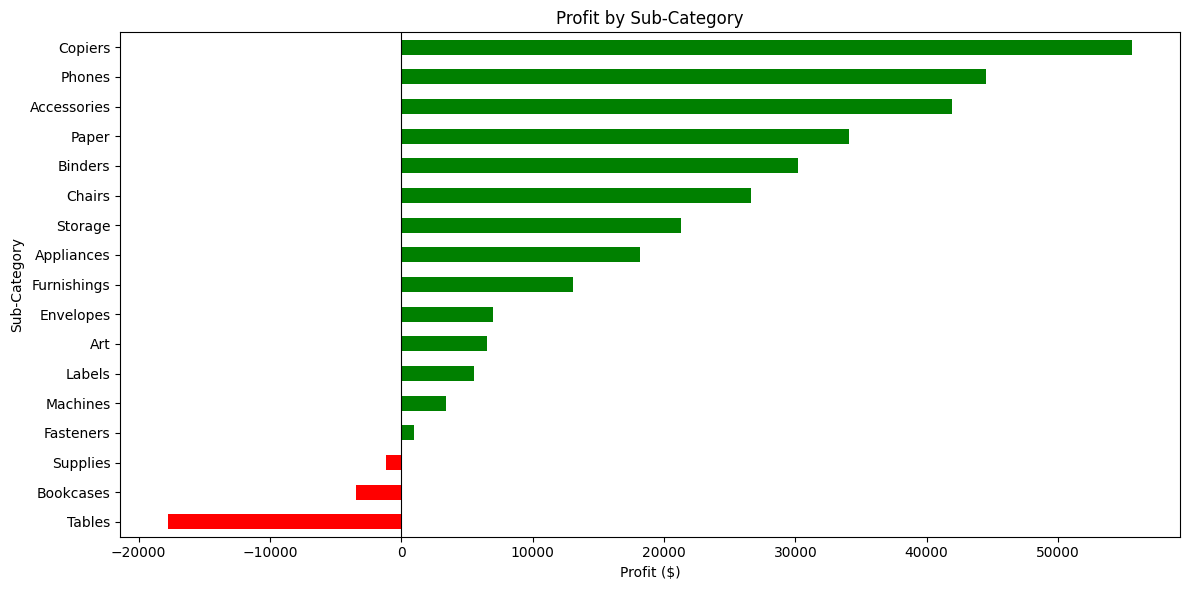

In [21]:
plt.figure(figsize = (12, 6))
subcat_perf['Profit'].sort_values().plot(kind = 'barh', color = subcat_perf['Profit'].sort_values().apply(lambda x: 'red' if x<0 else 'green'))
plt.title('Profit by Sub-Category')
plt.xlabel('Profit ($)')
plt.axvline(0, color = 'black', linewidth = 0.8)
plt.tight_layout()
plt.show()

In [23]:
df.groupby('Sub-Category')[['Discount', 'Profit']].mean().sort_values('Discount', ascending = False)

,Discount,Profit
Sub-Category,,
Binders,0.372292,19.843574
Machines,0.306087,29.432669
Tables,0.261285,-55.565771
Bookcases,0.211140,-15.230509
Chairs,0.170178,43.095894
Appliances,0.166524,38.922758
Copiers,0.161765,817.909190
Phones,0.154556,50.073938
Furnishings,0.138349,13.645918


In [26]:
# Regional Performance
region_perf = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Profit', ascending = False)
state_perf = df.groupby('State')[['Sales', 'Profit']].sum().sort_values('Profit').head(10)

print(region_perf)
print(state_perf)

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
South    391721.9050   46749.4303
Central  501239.8908   39706.3625
                      Sales      Profit
State                                  
Texas           170188.0458 -25729.3563
Ohio             78258.1360 -16971.3766
Pennsylvania    116511.9140 -15559.9603
Illinois         80166.1010 -12607.8870
North Carolina   55603.1640  -7490.9122
Colorado         32108.1180  -6527.8579
Tennessee        30661.8730  -5341.6936
Arizona          35282.0010  -3427.9246
Florida          89473.7080  -3399.3017
Oregon           17431.1500  -1190.4705


In [27]:
df[df['State'] == 'Texas'].groupby('Sub-Category')['Profit'].sum().sort_values().head(5)

Sub-Category
Binders       -14705.0738
Appliances     -6147.2225
Furnishings    -3312.6786
Machines       -2666.8434
Chairs         -2515.6490
Name: Profit, dtype: float64

In [28]:
segment_perf = df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values('Profit', ascending = False)
ship_perf = df.groupby('Ship Mode')[['Sales', 'Profit', 'Shipping Days']].agg({
    'Sales': 'sum', 'Profit': 'sum', 'Shipping Days': 'mean'})

print(segment_perf)
print(ship_perf)

                    Sales       Profit
Segment                               
Consumer     1.161401e+06  134119.2092
Corporate    7.061464e+05   91979.1340
Home Office  4.296531e+05   60298.6785
                       Sales       Profit  Shipping Days
Ship Mode                                               
First Class     3.514284e+05   48969.8399       2.182705
Same Day        1.283631e+05   15891.7589       0.044199
Second Class    4.591936e+05   57446.6354       3.238046
Standard Class  1.358216e+06  164088.7875       5.006535


In [29]:
# Export the full cleaned dataset

df.to_csv('../data/processed/superstore_cleaned.csv', index = False)

print("Exported successfully")
print(df.shape)

Exported successfully
(9994, 26)
